In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rcParams
from pathlib import Path
import numpy as np

# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

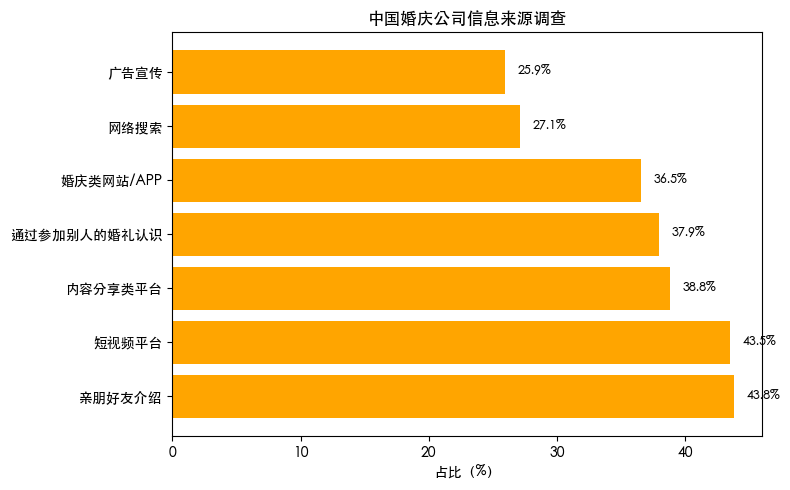

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
sources = [
    "亲朋好友介绍", "短视频平台", "内容分享类平台", 
    "通过参加别人的婚礼认识", "婚庆类网站/APP", "网络搜索", "广告宣传"
]
proportions = [43.8, 43.5, 38.8, 37.9, 36.5, 27.1, 25.9]

y = np.arange(len(sources))

fig, ax = plt.subplots(figsize=(8, 5))
# 绘制水平柱状图
bars = ax.barh(y, proportions, color='orange')

# 添加数值标注
for i, proportion in enumerate(proportions):
    ax.text(proportion + 1, i, f'{proportion}%', va='center', ha='left', fontsize=9)

# 设置y轴刻度和标签
ax.set_yticks(y)
ax.set_yticklabels(sources)
ax.set_xlabel('占比（%）')
ax.set_title('中国婚庆公司信息来源调查')

plt.tight_layout()
plt.show()

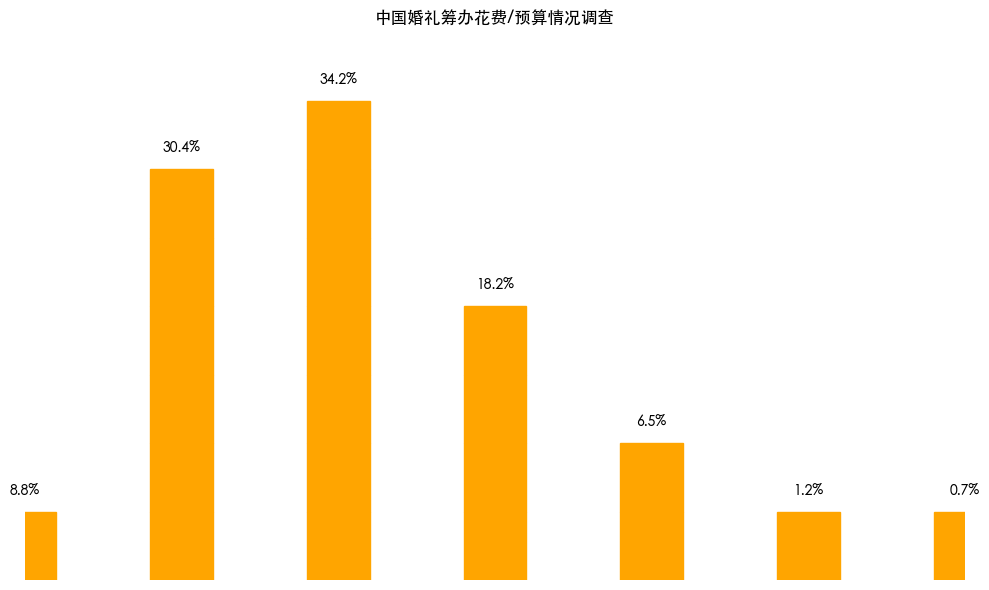

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 婚礼预算区间
categories = ["5万元以下", "5-10万元", "10-20万元", "20-30万元", "30-40万元", "40-50万元", "50万元以上"]
# 对应占比（%）
proportions = [8.8, 30.4, 34.2, 18.2, 6.5, 1.2, 0.7]
# 模拟钱袋数量（根据占比大致对应，可微调让视觉更接近原图）
bag_counts = [1, 6, 7, 4, 2, 1, 1]

x = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制“钱袋”柱状图（用多个小矩形模拟堆叠效果）
for i in range(len(categories)):
    for j in range(bag_counts[i]):
        rect = plt.Rectangle((x[i] - 0.2, j * 1), 0.4, 1, color='orange')
        ax.add_patch(rect)
        # 在最上方钱袋附近添加占比标注（只添加一次）
        if j == bag_counts[i] - 1:
            ax.text(x[i], (j + 1) * 1 + 0.2, f'{proportions[i]}%', ha='center', va='bottom')

# 设置坐标轴
ax.set_ylabel('钱袋堆叠示意')
ax.set_xlabel('预算区间')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, max(bag_counts) + 1)  # 预留空间显示标注
ax.axis('off')  # 隐藏默认坐标轴，突出钱袋样式

ax.set_title('中国婚礼筹办花费/预算情况调查')

plt.tight_layout()
plt.show()

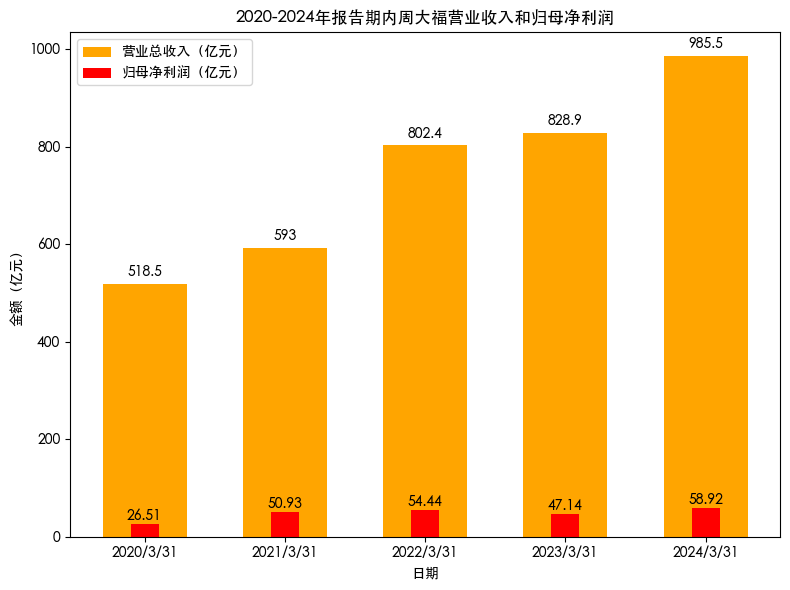

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 年份及日期
years = ["2020/3/31", "2021/3/31", "2022/3/31", "2023/3/31", "2024/3/31"]
# 营业总收入（亿元）
operating_revenue = [518.5, 593, 802.4, 828.9, 985.5]
# 归母净利润（亿元）
net_profit = [26.51, 50.93, 54.44, 47.14, 58.92]

x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(8, 6))

# 绘制营业总收入柱状图
ax.bar(x, operating_revenue, color='orange', label='营业总收入（亿元）', width=0.6)
# 绘制归母净利润柱状图
ax.bar(x, net_profit, color='red', label='归母净利润（亿元）', width=0.2)

# 添加营业总收入数值标注
for i, rev in enumerate(operating_revenue):
    ax.text(i, rev + 10, f'{rev}', ha='center', va='bottom')

# 添加归母净利润数值标注
for i, profit in enumerate(net_profit):
    ax.text(i, profit + 2, f'{profit}', ha='center', va='bottom')

ax.set_ylabel('金额（亿元）')
ax.set_xlabel('日期')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()
ax.set_title('2020-2024年报告期内周大福营业收入和归母净利润')

plt.tight_layout()
plt.show()

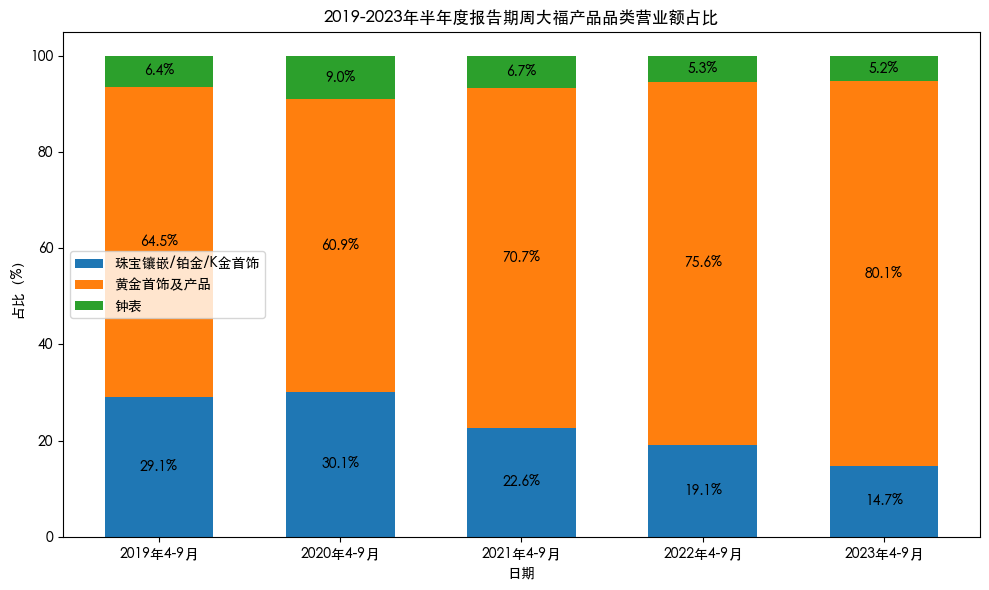

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 年份及日期
years = ["2019年4-9月", "2020年4-9月", "2021年4-9月", "2022年4-9月", "2023年4-9月"]
# 各品类占比（%），按 [珠宝镶嵌/铂金/K金首饰, 黄金首饰及产品, 钟表] 顺序
category_proportions = np.array([
    [29.1, 64.5, 6.4],
    [30.1, 60.9, 9.0],
    [22.6, 70.7, 6.7],
    [19.1, 75.6, 5.3],
    [14.7, 80.1, 5.2]
])

x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制堆积柱状图
bottom = np.zeros(len(years))
for i in range(category_proportions.shape[1]):
    ax.bar(x, category_proportions[:, i], bottom=bottom, width=0.6, label=['珠宝镶嵌/铂金/K金首饰', '黄金首饰及产品', '钟表'][i])
    # 添加数值标注
    for j in range(len(years)):
        ax.text(j, bottom[j] + category_proportions[j, i] / 2, f'{category_proportions[j, i]}%', ha='center', va='center')
    bottom += category_proportions[:, i]

ax.set_ylabel('占比（%）')
ax.set_xlabel('日期')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()
ax.set_title('2019-2023年半年度报告期周大福产品品类营业额占比')

plt.tight_layout()
plt.show()